In [22]:
import py7zr
import zipfile

import re
from collections import Counter

import json
from pathlib import Path

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from readers.rais_reader import RaisReader

from discovery.ftp_client import FTPClient
from discovery.filename_parser import RaisFilenameParser
from discovery.dataset_selector import RaisDatasetSelector

from profiling.schema_profiler import RaisSchemaProfiler

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

## Configuração de Paths

In [23]:
# Data paths
client_path = Path("/pdet/microdados/RAIS")
raw_data_path = Path("data/raw")
extracted_data_path = Path("data/extracted")
dict_dir = Path("dictionaries")

def save_json(path, doc):
    with open(path, "w") as file:
        json.dump(doc, file)

def load_json(path):
    def hint_tuples(item):
        if isinstance(item, dict):
            return {int(k) if k.isdigit() else k: v for k, v in item.items()}
        return item

    with open(path, "r") as file:
        arquivos = json.load(file, object_hook=hint_tuples)
    return arquivos

## Pré-processamento

### Parsing dos arquivos e seleção dos relevantes

In [3]:
client = FTPClient("ftp.mtps.gov.br")
client.connect()

arquivos = {}

for year in range(2020, 2021):
    try:
        arquivos[year] = client.list_directory(str(client_path.joinpath(str(year))))

        parser = RaisFilenameParser()
        parsed = [parser.parse(a) for a in arquivos[year]]

        selector = RaisDatasetSelector()
        arquivos[year] = selector.select_valid_datasets(parsed)

    except Exception as e:
        print(e)
        continue

client.disconnect()

In [ ]:
# Download documentos completos por ano

client = FTPClient("ftp.mtps.gov.br")

client.connect()

for year in range(2022, 2023):

    for arquivo in arquivos[year]:
        path_suffix = Path(f"{year}/{arquivo['filename']}")
        remote_file = client_path.joinpath(path_suffix)
        local_path = raw_data_path.joinpath(path_suffix)
        
        if local_path.exists():
            continue

        client.download_file(
            remote_file=remote_file,
            local_path=local_path
        )

client.disconnect()

In [ ]:
# Extrai documentos

for year in range(2020, 2021):
    arquivos_raw = [item for item in raw_data_path.joinpath(str(year)).iterdir() if item.is_file()]
    
    for a in arquivos_raw:
        dest_path = Path(str(a.parent).replace('raw', 'extracted')) 

        dest_path.mkdir(parents=True, exist_ok=True)

        if year < 2018 and dest_path.joinpath(a.stem + ".txt").exists():
            continue

        if year >= 2018 and dest_path.joinpath(a.stem + ".COMT").exists():
            continue
        
        if a.suffix == ".7z":
            with py7zr.SevenZipFile(str(a), mode="r") as z:
                z.extractall(path=dest_path)    
        
        elif a.suffix == ".zip":
            with zipfile.ZipFile(str(a), mode="r") as z:
                z.extractall(path=dest_path)

### Extração do schema dos dados

In [ ]:
profiler = RaisSchemaProfiler()
profiles = []

for year in range(2020, 2021):
    path = extracted_data_path.joinpath(str(year))

    if not path.exists():
        continue

    arquivos_extracted = [item for item in path.iterdir() if item.is_file()]

    for a in arquivos_extracted:
        profile = profiler.profile_schema(a)

        arquivo = next((item for item in arquivos[year] if item['stem'] == profile['file_name'].split('.')[0]))
        arquivo['profile'] = profile

save_json("data/arquivos.json", arquivos)

## Leitura e Processamento

### Leitura

In [ ]:
arquivos = load_json("data/arquivos.json")
reader = RaisReader()
data = {}
ds_type = "vinculo"

for year in range(2020, 2021):
    n_arqs = 0
    data[year] = {}

    for arquivo in arquivos[year]:
        n_arqs += 1

        if not arquivo["dataset_type"] == ds_type:
            continue

        if arquivo.get("profile"):
            profile = arquivo["profile"]
            data[year][arquivo["stem"]] = {}

            reader.configure(
                encoding=profile["encoding"],
                separator=profile["separator"]
            )

            filepath = (extracted_data_path / str(year) / profile["file_name"])
            print(filepath)

            for i, chunk in enumerate(reader.read(filepath)):
                data[year][arquivo['stem']][i] = chunk

                if i == 1:
                    break

### Normalização

In [ ]:
from normalization.normalizer import RaisNormalizer

normalizer = RaisNormalizer()
dfs = []

for regiao in data[2020]:
    for i in range(len(data[2020][regiao])):
        chunk = data[2020][regiao][i]
        chunk = normalizer.normalize(chunk, dataset_type="vinculo")
        dfs.append(chunk)

df = pd.concat(dfs).reset_index()
df = df.drop("sigla_uf", axis=1)
df = df.drop("categoria_trabalhador", axis=1)

### Seleção de colunas

In [ ]:
municipios = pd.read_csv("dictionaries/id_municipio.csv")
municipios = municipios[["id_municipio_6", "sigla_uf", "nome_uf"]].drop_duplicates()
municipios = municipios.rename(columns={"id_municipio_6": "id_municipio"})

df = df.merge(municipios, on="id_municipio", how="left")

cols = [
    "sexo",
    "raca_cor",
    "faixa_etaria",
    "grau_instrucao_apos_2005",
    "sigla_uf",
    "tamanho_estabelecimento",
    "tipo_vinculo",
    # "categoria_trabalhador",
    "subsetor_ibge",
    "valor_remuneracao_media"
]

df = df[cols]
df

### Tradução dos dicionários

In [ ]:
df["valor_remuneracao_media"] = pd.to_numeric(df["valor_remuneracao_media"].str.replace(',', '.'))
df = df[df["valor_remuneracao_media"] > 0].copy()

categorical_cols = [
    "sexo",
    "raca_cor",
    "faixa_etaria",
    "grau_instrucao_apos_2005",
    "tamanho_estabelecimento",
    "tipo_vinculo",
    # "categoria_trabalhador",
    "subsetor_ibge"
]

def apply_dictionary(df, column, dictionaries_path):
    path = dictionaries_path / f"{column}.csv"

    dictionary = pd.read_csv(path)
    dictionary = dictionary.copy()
    dictionary["chave"] = pd.to_numeric(dictionary["chave"], errors="coerce")
    dictionary = dictionary.dropna(subset=["chave"])
    dictionary["chave"] = dictionary["chave"].astype(int)

    mapping = dict(zip(dictionary["chave"], dictionary["valor"]))
    df[column] = df[column].map(mapping)

    return df

for col in categorical_cols:
    df = apply_dictionary(df, col, dict_dir)

df

### Limpeza

In [ ]:
for col in categorical_cols:
    print("\n")
    print(df[col].value_counts().head(10))

INVALID_VALUES = [
    "Não identificado",
    "IGNORADO",
    "Código não encontrado nos dicionários oficiais."
]

for col in [
    "sexo",
    "raca_cor",
    "faixa_etaria",
    "grau_instrucao_apos_2005",
    "tamanho_estabelecimento",
    "tipo_vinculo",
    # "categoria_trabalhador",
    "subsetor_ibge",
]:
    df = df[~df[col].isin(INVALID_VALUES)]

df = df.dropna()
df

df.to_csv("data/rais_2020.csv")

## Subset Mining

### Utils

In [ ]:
!pip install pysubgroup

In [4]:
import pysubgroup as ps

def create_target(df, percentile):
    threshold = df["valor_remuneracao_media"].quantile(percentile)

    target_col = f"target_p{int(percentile * 100)}"

    df[target_col] = (df["valor_remuneracao_media"] >= threshold)

    print(f"\nPercentil {percentile:.0%}")
    print(f"Threshold: R$ {threshold:.2f}")
    print(df[target_col].value_counts())
    print(df[target_col].value_counts(normalize=True))

    return target_col, threshold

### Carregamento dos dados

In [ ]:
df_2024 = pd.read_csv("data/rais_2024.csv")
df_2023 = pd.read_csv("data/rais_2023.csv")
df_2022 = pd.read_csv("data/rais_2022.csv")
df_2021 = pd.read_csv("data/rais_2021.csv")
df_2020 = pd.read_csv("data/rais_2020.csv")

dfs = {
    2020: df_2020,
    2021: df_2021,
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}

## Experimento 1 - Evolução dos Top Subgrupos (2020-2024)

In [ ]:
def prepare_mining_df(df, percentile=0.99):
    df = df.copy()

    threshold = df["valor_remuneracao_media"].quantile(percentile)
    df["target"] = (df["valor_remuneracao_media"] >= threshold)

    mining_df = df.copy()

    for col in [
        "sexo",
        "sigla_uf",
        "raca_cor",
        "faixa_etaria",
        "tipo_vinculo",
        "subsetor_ibge",
        "tamanho_estabelecimento",
        "grau_instrucao_apos_2005",
    ]:
        mining_df[col] = mining_df[col].astype(str)

    search_space = ps.create_selectors(mining_df, ignore=["valor_remuneracao_media", "target"])

    return mining_df, search_space


def run_sd(mining_df, search_space, depth=4, result_size=20):
    target = ps.BinaryTarget("target", True)

    task = ps.SubgroupDiscoveryTask(
        mining_df,
        target,
        search_space,
        result_set_size=result_size,
        depth=depth,
        qf=ps.StandardQF(0.5)
    )

    result = ps.BeamSearch(beam_width=result_size * 2).execute(task)

    return result

In [ ]:
results = {}

for year, df in dfs.items():
    print(year)
    mining_df, search_space = prepare_mining_df(df, percentile=0.99)
    result = run_sd(mining_df, search_space)
    results[year] = result

results

In [ ]:
results_df = {}

for year, result in results.items():
    results_df[year] = (result.to_dataframe().sort_values("quality", ascending=False))

In [5]:
results_2020 = pd.read_csv("data/results_2020.csv")
results_2021 = pd.read_csv("data/results_2021.csv")
results_2022 = pd.read_csv("data/results_2022.csv")
results_2023 = pd.read_csv("data/results_2023.csv")
results_2024 = pd.read_csv("data/results_2024.csv")

results_df = {
    2020: results_2020,
    2021: results_2021,
    2022: results_2022,
    2023: results_2023,
    2024: results_2024
}

In [7]:
for year in range(2020, 2025):
    print("\n")
    print("=" * 80)
    print(year)

    display(
        results_df[year][
            ["subgroup", "lift", "coverage_sg", "target_share_sg"]
        ].head(10)
    )



2020


,subgroup,lift,coverage_sg,target_share_sg
0,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,19.259563,0.345533,0.192600
1,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,20.989656,0.313131,0.209902
2,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,59.216479,0.097337,0.592179
3,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,58.752556,0.097731,0.587539
4,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,52.518140,0.106651,0.525194
5,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,51.742596,0.107044,0.517438
6,grau_instrucao_apos_2005=='SUP. COMP',16.067587,0.369671,0.160680
7,grau_instrucao_apos_2005=='SUP. COMP' AND tipo...,17.262622,0.335432,0.172630
8,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,26.457385,0.178539,0.264580
9,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,23.891414,0.197298,0.238920




2021


,subgroup,lift,coverage_sg,target_share_sg
0,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,21.306218,0.283836,0.213070
1,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,19.896142,0.305433,0.198969
2,grau_instrucao_apos_2005=='SUP. COMP',15.633207,0.335345,0.156338
3,grau_instrucao_apos_2005=='SUP. COMP' AND tipo...,16.553626,0.309457,0.165542
4,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,53.708230,0.081556,0.537102
5,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,52.715880,0.081958,0.527179
6,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,47.253263,0.091214,0.472550
7,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,46.339723,0.091751,0.463415
8,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,27.908871,0.147954,0.279099
9,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,25.619953,0.157746,0.256209




2022


,subgroup,lift,coverage_sg,target_share_sg
0,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,48.001161,0.075809,0.480074
1,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,46.576666,0.075809,0.465827
2,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,55.214553,0.056491,0.552217
3,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,54.206422,0.056491,0.542135
4,"subsetor_ibge=='Instituiçoes de crédito, segur...",29.848120,0.103322,0.298520
5,"subsetor_ibge=='Instituiçoes de crédito, segur...",26.527923,0.103322,0.265314
6,sexo=='Masculino' AND subsetor_ibge=='Institui...,32.984768,0.079467,0.329891
7,sexo=='Masculino' AND subsetor_ibge=='Institui...,29.668266,0.079467,0.296721
8,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,53.760818,0.038636,0.537678
9,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,52.898921,0.038636,0.529058




2023


,subgroup,lift,coverage_sg,target_share_sg
0,categoria_trabalhador==' Servidor público titu...,28.532038,0.127494,0.285331
1,categoria_trabalhador==' Servidor público titu...,20.120528,0.184191,0.201213
2,categoria_trabalhador==' Servidor público titu...,18.276653,0.195740,0.182773
3,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,8.014764,0.428079,0.080151
4,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,6.180707,0.595620,0.061809
5,categoria_trabalhador==' Servidor público titu...,22.985088,0.122394,0.229859
6,categoria_trabalhador==' Servidor público titu...,21.345865,0.128394,0.213466
7,categoria_trabalhador==' Servidor público titu...,11.884006,0.233838,0.118844
8,categoria_trabalhador==' Servidor público titu...,16.976406,0.151792,0.169770
9,categoria_trabalhador==' Servidor público titu...,20.124758,0.125094,0.201255




2024


,subgroup,lift,coverage_sg,target_share_sg
0,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,7.990160,0.432833,0.079916
1,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,6.057311,0.608155,0.060584
2,"subsetor_ibge=='Instituiçoes de crédito, segur...",30.763684,0.073820,0.307692
3,categoria_trabalhador==' Contribuinte individu...,30.763684,0.073820,0.307692
4,categoria_trabalhador==' Contribuinte individu...,30.763684,0.073820,0.307692
5,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,30.303236,0.069528,0.303087
6,categoria_trabalhador==' Contribuinte individu...,30.303236,0.069528,0.303087
7,categoria_trabalhador==' Contribuinte individu...,30.303236,0.069528,0.303087
8,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,5.035929,0.592704,0.050368
9,faixa_etaria=='50 a 64 anos' AND grau_instruca...,10.515651,0.216738,0.105175


## Experimento 2 - Frequência dos atributos ao longo do tempo

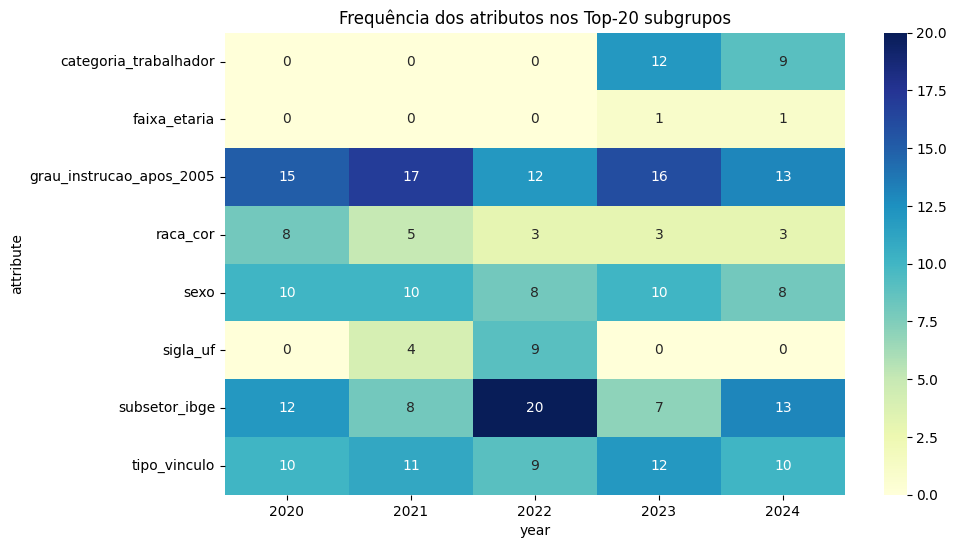

In [9]:
def attribute_frequency(result_df):
    counter = Counter()

    for subgroup in result_df["subgroup"]:
        subgroup = str(subgroup)
        attrs = attrs = re.findall(r"([\w]+)\s*==", subgroup)
        counter.update(attrs)

    return counter


attribute_counts = {}

for year in results_df:
    attribute_counts[year] = attribute_frequency(results_df[year])

rows = []

for year, counter in attribute_counts.items():
    for attr, freq in counter.items():
        rows.append({"year": year, "attribute": attr, "frequency": freq})

attribute_df = pd.DataFrame(rows)
attribute_pivot = (
    attribute_df.pivot(index="attribute", columns="year", values="frequency")
    .fillna(0)
)

plt.figure(figsize=(10, 6))
sns.heatmap(attribute_pivot, annot=True, cmap="YlGnBu")
plt.title("Frequência dos atributos nos Top-20 subgrupos")
plt.show()

## Experimento 3 - Top valores nos subgrupos

In [10]:
def value_frequency(result_df):
    counter = Counter()

    for subgroup in result_df["subgroup"]:
        subgroup = str(subgroup)
        values = re.findall(r"==\s*'([^']+)'", subgroup)
        counter.update(values)

    return counter


value_counts = {}

for year in results_df:
    value_counts[year] = value_frequency(results_df[year])

for year in sorted(value_counts):
    print("\n" + "=" * 80)
    print(year)

    for value, freq in value_counts[year].most_common(15):
        print(freq, value)


2020
15 SUP. COMP
12 Instituiçoes de crédito, seguros e capitalizaçao
10 Masculino
10 CLT U/PJ IND
8 Branca

2021
17 SUP. COMP
11 CLT U/PJ IND
10 Masculino
8 Instituiçoes de crédito, seguros e capitalizaçao
5 Branca
4 MA

2022
20 Instituiçoes de crédito, seguros e capitalizaçao
12 SUP. COMP
9 CLT U/PJ IND
8 Masculino
7 MA
3 Branca
2 RO

2023
16 SUP. COMP
12  Servidor público titular de cargo efetivo magistrado ministro de Tribunal de Contas conselheiro de Tribunal de Contas e membro do Ministério Público
12 ESTATUTARIO
10 Masculino
7 Administraçao pública direta e autárquica
3 Branca
1 50 a 64 anos

2024
13 SUP. COMP
12 Instituiçoes de crédito, seguros e capitalizaçao
8 Masculino
7 DIRETOR
6  Contribuinte individual - Diretor não empregado com FGTS
3 Branca
3  Servidor público titular de cargo efetivo magistrado ministro de Tribunal de Contas conselheiro de Tribunal de Contas e membro do Ministério Público
3 ESTATUTARIO
1 50 a 64 anos
1 Administraçao pública direta e autárquica


## Experimento 4 - Evolução temporal do melhor subgrupo

In [11]:
best_subgroups = []

for year, result_df in results_df.items():
    best = result_df.sort_values("lift", ascending=False).iloc[0]

    best_subgroups.append({
        "year": year,
        "subgroup": best["subgroup"],
        "lift": best["lift"],
        "coverage": best["coverage_sg"],
        "target_share": best["target_share_sg"]
    })

best_df = pd.DataFrame(best_subgroups)
best_df

,year,subgroup,lift,coverage,target_share
0,2020,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,62.966428,0.061787,0.629679
1,2021,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,54.299036,0.054192,0.543011
2,2022,grau_instrucao_apos_2005=='SUP. COMP' AND sigl...,63.202469,0.027660,0.632107
3,2023,categoria_trabalhador==' Servidor público titu...,28.532038,0.127494,0.285331
4,2024,categoria_trabalhador==' Contribuinte individu...,30.911754,0.058584,0.309173


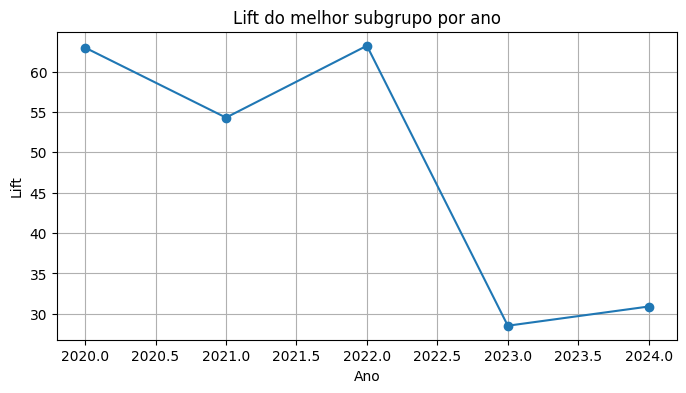

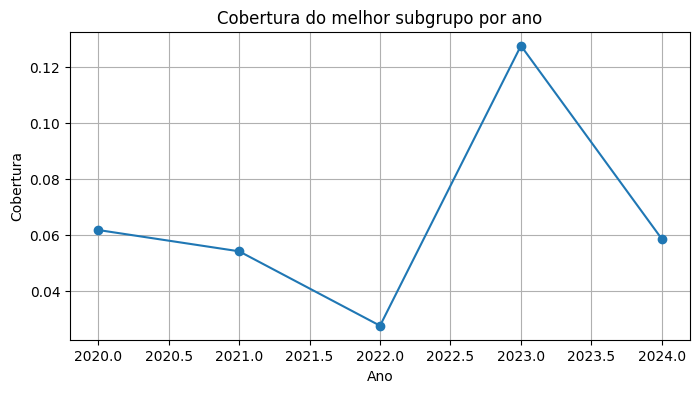

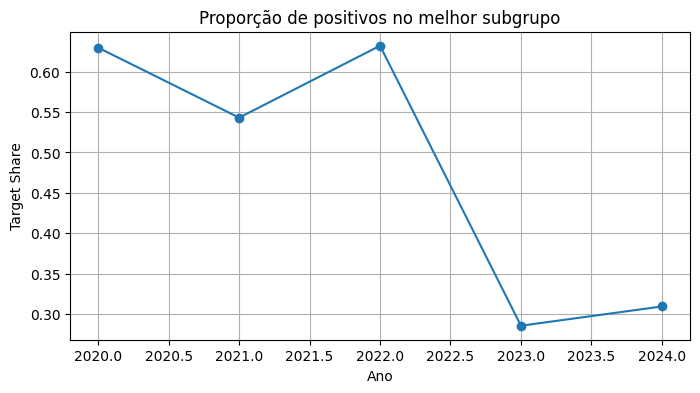

,year,lift,coverage,target_share
0,2020,62.966,0.062,0.630
1,2021,54.299,0.054,0.543
2,2022,63.202,0.028,0.632
3,2023,28.532,0.127,0.285
4,2024,30.912,0.059,0.309


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(best_df["year"], best_df["lift"], marker="o")
plt.title("Lift do melhor subgrupo por ano")
plt.ylabel("Lift")
plt.xlabel("Ano")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best_df["year"], best_df["coverage"], marker="o")
plt.title("Cobertura do melhor subgrupo por ano")
plt.ylabel("Cobertura")
plt.xlabel("Ano")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best_df["year"], best_df["target_share"], marker="o")
plt.title("Proporção de positivos no melhor subgrupo")
plt.ylabel("Target Share")
plt.xlabel("Ano")
plt.grid(True)
plt.show()

best_df[["year", "lift", "coverage", "target_share"]].round(3)

## Experimento 5 - Evolução temporal dos setores

In [ ]:
dfs = {
    2020: df_2020,
    2021: df_2021,
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}

for year, df in dfs.items():
    threshold = df["valor_remuneracao_media"].quantile(0.99)
    df["target_p99"] = (df["valor_remuneracao_media"] >= threshold)

In [ ]:
sector_stats = []

for year, df in dfs.items():
    temp = (
        df.groupby("subsetor_ibge")
        .agg(
            total=("target_p99", "size"),
            positives=("target_p99", "sum"),
            mean_salary=("valor_remuneracao_media", "mean")
        )
        .reset_index()
    )

    temp["share_top1"] = temp["positives"] / temp["total"]
    temp["year"] = year
    sector_stats.append(temp)

sector_stats = pd.concat(sector_stats, ignore_index=True)
sector_stats.head()

In [ ]:
for year in sorted(sector_stats["year"].unique()):
    print("\n" + "=" * 80)
    print(year)

    display(
        sector_stats[sector_stats["year"] == year]
        .sort_values("share_top1", ascending=False)
        [["subsetor_ibge", "share_top1", "mean_salary", "total"]]
        .head(10)
    )

In [ ]:
interesting_sectors = [
    "Instituiçoes de crédito, seguros e capitalizaçao",
    "Administraçao pública direta e autárquica"
]

sector_evolution = sector_stats[sector_stats["subsetor_ibge"].isin(interesting_sectors)]

plt.figure(figsize=(10, 5))

for sector in interesting_sectors:
    subset = sector_evolution[sector_evolution["subsetor_ibge"] == sector]
    plt.plot(subset["year"], subset["share_top1"], marker="o", label=sector)

plt.title("Participação no Top 1% por setor")
plt.xlabel("Ano")
plt.ylabel("% Top 1%")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))

for sector in interesting_sectors:
    subset = sector_evolution[sector_evolution["subsetor_ibge"] == sector]
    plt.plot(subset["year"], subset["mean_salary"], marker="o", label=sector)

plt.title("Salário médio por setor")
plt.xlabel("Ano")
plt.ylabel("Remuneração média")
plt.legend()
plt.grid(True)
plt.show()

## Experimento 6 - Estabilidade dos padrões

In [14]:
top_subgroups = {}

for year, result_df in results_df.items():
    top_subgroups[year] = set(result_df["subgroup"].head(20))


def jaccard_similarity(set_a, set_b):
    intersection = len(set_a.intersection(set_b))
    union = len(set_a.union(set_b))
    return intersection / union


years = sorted(top_subgroups.keys())

jaccard_matrix = pd.DataFrame(index=years, columns=years, dtype=float)

for y1 in years:
    for y2 in years:
        jaccard_matrix.loc[y1, y2] = jaccard_similarity(top_subgroups[y1], top_subgroups[y2])

jaccard_matrix

,2020,2021,2022,2023,2024
2020,1.000000,0.666667,0.379310,0.081081,0.176471
2021,0.666667,1.000000,0.250000,0.081081,0.176471
2022,0.379310,0.250000,1.000000,0.000000,0.052632
2023,0.081081,0.081081,0.000000,1.000000,0.212121
2024,0.176471,0.176471,0.052632,0.212121,1.000000


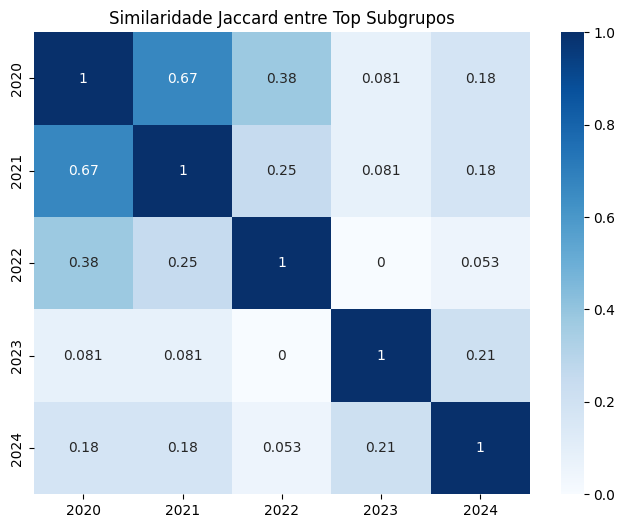

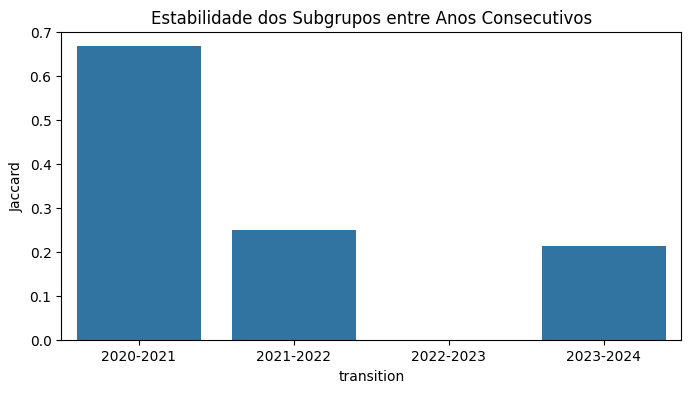

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_matrix, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Similaridade Jaccard entre Top Subgrupos")
plt.show()

adjacent_years = []

for i in range(len(years) - 1):
    y1 = years[i]
    y2 = years[i + 1]

    adjacent_years.append({
        "transition": f"{y1}-{y2}",
        "jaccard": jaccard_matrix.loc[y1, y2]
    })

adjacent_df = pd.DataFrame(adjacent_years)
adjacent_df

plt.figure(figsize=(8, 4))
sns.barplot(data=adjacent_df, x="transition", y="jaccard")
plt.title("Estabilidade dos Subgrupos entre Anos Consecutivos")
plt.ylabel("Jaccard")
plt.show()

## Experimento 7 - Similaridade Semântica dos Subgrupos

In [16]:
def subgroup_to_tokens(subgroup):
    subgroup = str(subgroup)
    values = re.findall(r"==\s*'([^']+)'", subgroup)
    return set(values)


semantic_sets = {}

for year, result_df in results_df.items():
    tokens = set()

    for subgroup in result_df["subgroup"].head(20):
        tokens.update(subgroup_to_tokens(subgroup))

    semantic_sets[year] = tokens


semantic_jaccard = pd.DataFrame(index=years, columns=years, dtype=float)

for y1 in years:
    for y2 in years:
        semantic_jaccard.loc[y1, y2] = jaccard_similarity(semantic_sets[y1], semantic_sets[y2])

semantic_jaccard

,2020,2021,2022,2023,2024
2020,1.000000,0.833333,0.714286,0.333333,0.363636
2021,0.833333,1.000000,0.857143,0.300000,0.333333
2022,0.714286,0.857143,1.000000,0.272727,0.307692
2023,0.333333,0.300000,0.272727,1.000000,0.700000
2024,0.363636,0.333333,0.307692,0.700000,1.000000


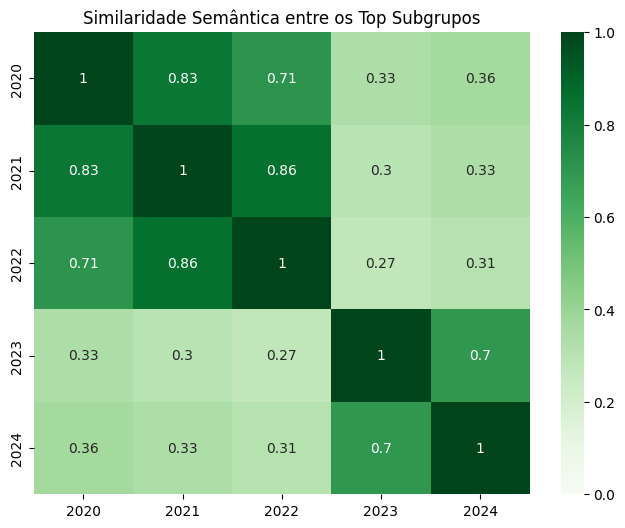

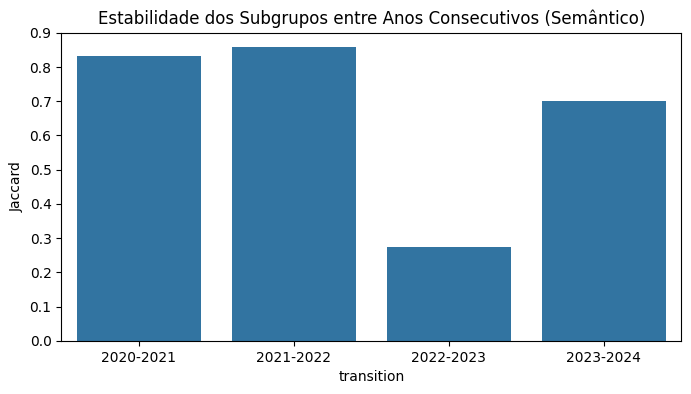

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(semantic_jaccard, annot=True, cmap="Greens", vmin=0, vmax=1)
plt.title("Similaridade Semântica entre os Top Subgrupos")
plt.show()

comparisons = []

for i in range(len(years) - 1):
    y1 = years[i]
    y2 = years[i + 1]

    comparisons.append({
        "transition": f"{y1}-{y2}",
        "textual_jaccard": jaccard_matrix.loc[y1, y2],
        "semantic_jaccard": semantic_jaccard.loc[y1, y2]
    })

comparison_df = pd.DataFrame(comparisons)
comparison_df

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x="transition", y="semantic_jaccard")
plt.title("Estabilidade dos Subgrupos entre Anos Consecutivos (Semântico)")
plt.ylabel("Jaccard")
plt.show()

## Experimento 7.5 - Qualidade média dos top-20

In [18]:
summary = []

for year, df in results_df.items():
    summary.append({
        "year": year,
        "mean_lift": df["lift"].head(20).mean(),
        "mean_target_share": df["target_share_sg"].head(20).mean(),
        "mean_coverage": df["coverage_sg"].head(20).mean()
    })

summary_df = pd.DataFrame(summary)
summary_df

,year,mean_lift,mean_target_share,mean_coverage
0,2020,37.026643,0.370275,0.165617
1,2021,30.314046,0.303152,0.161818
2,2022,47.052502,0.470586,0.053886
3,2023,14.781096,0.147816,0.230478
4,2024,21.213886,0.212177,0.198605


## Experimento 8 - Evolução Regional do Top 1%

In [ ]:
regional_stats = []

for year, df in dfs.items():
    threshold = df["valor_remuneracao_media"].quantile(0.99)

    df = df.copy()
    df["target_p99"] = (df["valor_remuneracao_media"] >= threshold)

    temp = (
        df.groupby("sigla_uf")
        .agg(
            total=("target_p99", "size"),
            positives=("target_p99", "sum"),
            mean_salary=("valor_remuneracao_media", "mean")
        )
        .reset_index()
    )

    temp["share_top1"] = temp["positives"] / temp["total"]
    temp["year"] = year
    regional_stats.append(temp)

regional_stats = pd.concat(regional_stats, ignore_index=True)
regional_stats.head()

In [ ]:
for year in sorted(regional_stats["year"].unique()):
    print("\n" + "=" * 80)
    print(year)

    display(
        regional_stats[regional_stats["year"] == year]
        .sort_values("share_top1", ascending=False)
        [["sigla_uf", "share_top1", "mean_salary", "total"]]
        .head(10)
    )

In [ ]:
regional_pivot = (
    regional_stats.pivot(index="sigla_uf", columns="year", values="share_top1")
    .fillna(0)
)

plt.figure(figsize=(10, 12))
sns.heatmap(regional_pivot, cmap="YlOrRd", annot=True)
plt.title("Participação no Top 1% por Estado")
plt.show()

state_means = (
    regional_stats.groupby("sigla_uf")["share_top1"]
    .mean()
    .sort_values(ascending=False)
)

top_states = state_means.head(5).index.tolist()
top_states

plt.figure(figsize=(10, 5))

for state in top_states:
    subset = regional_stats[regional_stats["sigla_uf"] == state]
    plt.plot(subset["year"], subset["share_top1"], marker="o", label=state)

plt.title("Estados com Maior Participação no Top 1%")
plt.xlabel("Ano")
plt.ylabel("Share Top 1%")
plt.legend()
plt.grid(True)
plt.show()

## Experimento 8.5 - Subgroup Discovery Regional

In [20]:
def run_state_sd(df, uf):
    state_df = df[df["sigla_uf"] == uf].copy()

    target_col, threshold = create_target(state_df, percentile=0.99)

    search_space = ps.create_selectors(
        state_df,
        ignore=["valor_remuneracao_media", target_col]
    )

    target = ps.BinaryTarget(target_col, True)

    task = ps.SubgroupDiscoveryTask(
        state_df,
        target,
        search_space,
        result_set_size=10,
        depth=2,
        qf=ps.StandardQF(0.5)
    )

    result = ps.BeamSearch(beam_width=20).execute(task)

    return result.to_dataframe().sort_values("quality", ascending=False)

In [ ]:
state_year = {
    "MA": 2022,
    "RO": 2022,
    "MS": 2022,
    "DF": 2024,
    "RJ": 2024,
    "SP": 2024
}

state_results = {}

for state, year in state_year.items():
    print("\n")
    print("=" * 80)
    print(state, year)

    result_df = run_state_sd(dfs[year], state)
    state_results[state] = result_df

    display(
        result_df[["subgroup", "lift", "coverage_sg", "target_share_sg"]]
    )

In [ ]:
rows = []

for state, result_df in state_results.items():
    counter = attribute_frequency(result_df)

    for attr, freq in counter.items():
        rows.append({"state": state, "attribute": attr, "frequency": freq})

attribute_df = pd.DataFrame(rows)
attribute_pivot = (
    attribute_df.pivot(index="attribute", columns="state", values="frequency")
    .fillna(0)
)

attribute_pivot

plt.figure(figsize=(12, 6))
sns.heatmap(attribute_pivot, annot=True, cmap="YlGnBu")
plt.title("Frequência dos atributos nos Top Subgrupos por Estado")
plt.show()

In [ ]:
for state in state_results:
    print("\n")
    print("=" * 80)
    print(state)

    counter = value_frequency(state_results[state])

    for value, freq in counter.most_common(15):
        print(freq, value)

## Experimento 9 - Evolução da importância dos atributos

In [ ]:
def attribute_importance(df):
    df = df.copy()

    target_col, _ = create_target(df, 0.99)

    X = df.drop(columns=["valor_remuneracao_media", target_col])
    y = df[target_col]

    X_encoded = pd.DataFrame()

    for col in X.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X[col].astype(str))

    mi = mutual_info_classif(
        X_encoded,
        y,
        discrete_features=True,
        random_state=42
    )

    return pd.DataFrame({
        "attribute": X.columns,
        "mutual_information": mi
    }).sort_values("mutual_information", ascending=False)


importance_results = []

for year, df in dfs.items():
    imp = attribute_importance(df)
    imp["year"] = year
    importance_results.append(imp)

importance_df = pd.concat(importance_results, ignore_index=True)
importance_df.head()

In [ ]:
importance_df

importance_pivot = importance_df.pivot(
    index="attribute",
    columns="year",
    values="mutual_information"
)

plt.figure(figsize=(10, 6))
sns.heatmap(importance_pivot, annot=True, cmap="YlGnBu")
plt.title("Importância dos atributos para identificar o Top 1%")
plt.show()